In [4]:
import importlib , math
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import bookworm
import tools
import evaluate
import matplotlib.pyplot as plt
from IPython.display import display

from bookworm import execute_action


In [6]:
book_id =11

In [5]:
try:
    display(execute_action(action_type="lexdiv", book_id=book_id))
except ValueError as e:
    print(e)

{'tok': 30528,
 'typ': 2855,
 'hap': 1349,
 'ttr': 0.09352070230607966,
 'mwl': 3.6723663522012577,
 'mwf': 10.692819614711034}

In [6]:
try:
    display(execute_action(action_type="topics", book_id=book_id))
except ValueError as e:
    print(e)

{'1': ['alice',
  'little',
  'rabbit',
  'key',
  'way',
  'eat',
  'think',
  'bats',
  'like',
  'door'],
 '2': ['mouse',
  'alice',
  'pool',
  'little',
  'cats',
  'oh',
  'swam',
  'll',
  'dear',
  'said'],
 '3': ['said',
  'mouse',
  'dodo',
  'alice',
  'race',
  'lory',
  'prizes',
  'dry',
  'thimble',
  'know'],
 '4': ['alice',
  'little',
  'window',
  'rabbit',
  'puppy',
  'gloves',
  'chimney',
  'fan',
  'bottle',
  'said'],
 '5': ['caterpillar',
  'said',
  'alice',
  'pigeon',
  'serpent',
  'youth',
  'eggs',
  'father',
  'size',
  'little'],
 '6': ['said',
  'alice',
  'footman',
  'cat',
  'baby',
  'mad',
  'duchess',
  'pig',
  'wow',
  'like'],
 '7': ['hatter',
  'dormouse',
  'said',
  'alice',
  'march',
  'hare',
  'tea',
  'time',
  'twinkle',
  'draw'],
 '8': ['queen',
  'said',
  'alice',
  'king',
  'gardeners',
  'soldiers',
  'hedgehog',
  'cat',
  'executioner',
  'procession'],
 '9': ['turtle',
  'said',
  'mock',
  'alice',
  'gryphon',
  'duchess

In [7]:
try:
    display(execute_action(action_type="entities", book_id=book_id))
except ValueError as e:
    print(e)

{'characters': ['Alice',
  'Beautiful',
  'Bill',
  'Dinah',
  'Don',
  'Dormouse',
  'Father William',
  'Gryphon',
  'Hare',
  'Hatter',
  'Mabel',
  'Queen',
  'Seven',
  'William'],
 'locations': ['Alice',
  'Cheshire',
  'England',
  'France',
  'Gryphon',
  'Hearts',
  'King',
  'Pigeon',
  'Time',
  'Wonderland']}

In [8]:
try:
    display(execute_action(action_type="summarize", book_id=book_id))
except ValueError as e:
    print(e)

'Hardly knowing what she did, she picked up a little bit of stick, and held it out to the puppy; whereupon the puppy jumped into the air off all its feet at once, with a yelp of delight, and rushed at the stick, and made believe to worry it; then Alice dodged behind a great thistle, to keep herself from being run over; and the moment she appeared on the other side, the puppy made another rush at the stick, and tumbled head over heels in its hurry to get hold of it; then Alice, thinking it was very like having a game of play with a cart-horse, and expecting every moment to be trampled under its feet, ran round the thistle again; then the puppy began a series of short charges at the stick, running a very little way forwards each time and a long way back, and barking hoarsely all the while, till at last it sat down a good way off, panting, with its tongue hanging out of its mouth, and its great eyes half shut. The chief difficulty Alice found at first was in managing her flamingo: she suc

In [9]:
try:
    display(execute_action(action_type="similar", book_id=book_id))
except ValueError as e:
    print(e)

['Through the Looking-Glass',
 'The Memoirs of Sherlock Holmes',
 'Treasure Island',
 'The Adventures of Sherlock Holmes',
 'The Time Machine']

Evaluation du similar

In [10]:
similar_own = execute_action(action_type="similar", book_id=book_id, own=True)
similar= execute_action(action_type="similar", book_id=book_id)

In [11]:
result_similar = evaluate.compare_resulte(own_result=similar_own,ref_result=similar)
print(result_similar)

{'Precision_model': 80.0, 'Precision_ref': 80.0, 'F1_score': 80.0, 'Total_Token_own': 5, 'Total_Token_ref': 5}


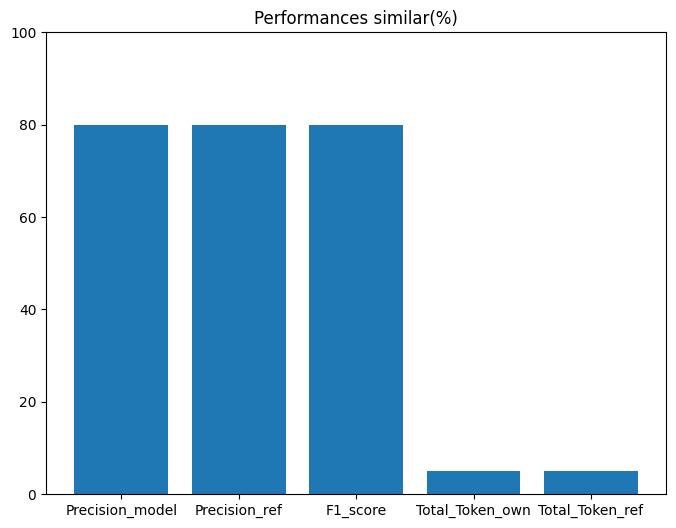

In [12]:
plt.figure(figsize=(8,6))
plt.bar(result_similar.keys(),result_similar.values())
plt.ylim(0,100)
plt.title("Performances similar(%)")

plt.show()

Evaluation du topics

In [13]:
topics_own = execute_action(action_type="topics", book_id=book_id, own=True)
topics= execute_action(action_type="topics", book_id=book_id)
print (topics_own)
print(topics)

{'1': ['alice', 'little', 'rabbit', 'key', 'way', 'eat', 'bats', 'like', 'think', 'either'], '2': ['mouse', 'alice', 'pool', 'little', 'cats', 'oh', 'swam', 'dear', 'said', 'mabel'], '3': ['said', 'mouse', 'dodo', 'alice', 'race', 'lory', 'prizes', 'dry', 'thimble', 'know'], '4': ['alice', 'bill', 'little', 'window', 'rabbit', 'puppy', 'gloves', 'chimney', 'one', 'bottle'], '5': ['caterpillar', 'said', 'alice', 'pigeon', 'serpent', 'youth', 'eggs', 'father', 'size', 'little'], '6': ['said', 'alice', 'footman', 'cat', 'baby', 'mad', 'duchess', 'pig', 'wow', 'like'], '7': ['hatter', 'dormouse', 'said', 'alice', 'march', 'hare', 'tea', 'twinkle', 'time', 'well'], '8': ['queen', 'said', 'alice', 'king', 'gardeners', 'soldiers', 'hedgehog', 'cat', 'five', 'executioner'], '9': ['turtle', 'said', 'mock', 'alice', 'gryphon', 'duchess', 'moral', 'queen', 'went', 'school'], '10': ['turtle', 'mock', 'gryphon', 'said', 'dance', 'alice', 'soup', 'join', 'beautiful', 'whiting'], '11': ['king', 'hatt

In [14]:
result_topics = {}

for chapter, word_own in topics_own.items():
    word_ref = topics[chapter]
    scores = evaluate.compare_resulte(word_own , word_ref)
    result_topics[f"ch :{chapter}"]= scores

print(result_topics)


{'ch :1': {'Precision_model': 90.0, 'Precision_ref': 90.0, 'F1_score': 90.0, 'Total_Token_own': 10, 'Total_Token_ref': 10}, 'ch :2': {'Precision_model': 90.0, 'Precision_ref': 90.0, 'F1_score': 90.0, 'Total_Token_own': 10, 'Total_Token_ref': 10}, 'ch :3': {'Precision_model': 100.0, 'Precision_ref': 100.0, 'F1_score': 100.0, 'Total_Token_own': 10, 'Total_Token_ref': 10}, 'ch :4': {'Precision_model': 80.0, 'Precision_ref': 80.0, 'F1_score': 80.0, 'Total_Token_own': 10, 'Total_Token_ref': 10}, 'ch :5': {'Precision_model': 100.0, 'Precision_ref': 100.0, 'F1_score': 100.0, 'Total_Token_own': 10, 'Total_Token_ref': 10}, 'ch :6': {'Precision_model': 100.0, 'Precision_ref': 100.0, 'F1_score': 100.0, 'Total_Token_own': 10, 'Total_Token_ref': 10}, 'ch :7': {'Precision_model': 90.0, 'Precision_ref': 90.0, 'F1_score': 90.0, 'Total_Token_own': 10, 'Total_Token_ref': 10}, 'ch :8': {'Precision_model': 90.0, 'Precision_ref': 90.0, 'F1_score': 90.0, 'Total_Token_own': 10, 'Total_Token_ref': 10}, 'ch :9

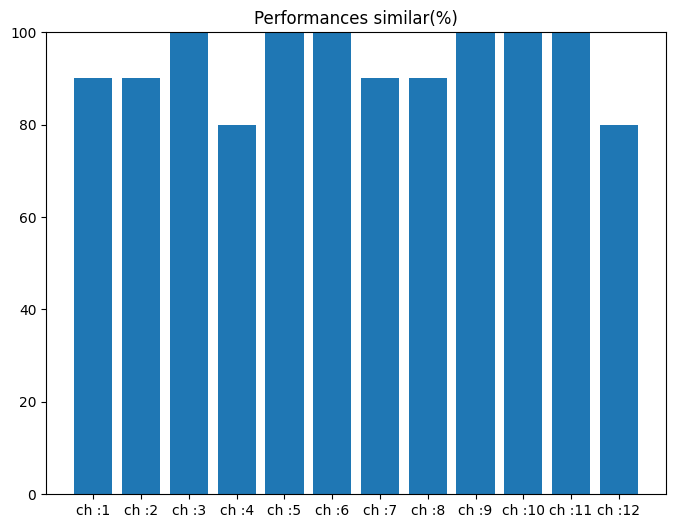

In [15]:
f1 = [scores["F1_score"] for scores in result_topics.values()]
precision =[scores["Precision_model"] for scores in result_topics.values()]


plt.figure(figsize=(8,6))
plt.bar(result_topics.keys(),f1)
plt.ylim(0,100)
plt.title("Performances similar(%)")

plt.show()

Explication vectorisation
On a 
Phase 1 : chat
Phase 2 : chat et chien
Phase 3 : chien

Donc tableau : 

            Chat chien
phrase 1      1    0
phrase 2      1    1
phrase 3      0    1
On a donc  3 vecteurs : [1.0] [1.1] [0.1]


Création vecteurs

In [3]:
vect_A = np.array([1,0])
vect_B = np.array([1,1]) 
vect_C = np.array([0,1])


Calcul du score cosinus

In [4]:
sim_AB = cosine_similarity([vect_A], [vect_B])[0][0]
sim_AC = cosine_similarity([vect_A], [vect_C])[0][0]
sim_BC = cosine_similarity([vect_B], [vect_C])[0][0]

In [ ]:
print(sim_AB) 
print(sim_AC)
print(sim_BC)



0.7071067811865475
0.0
0.7071067811865475


In [ ]:
print(math.degrees(math.acos(sim_AB)))

45.00000000000001


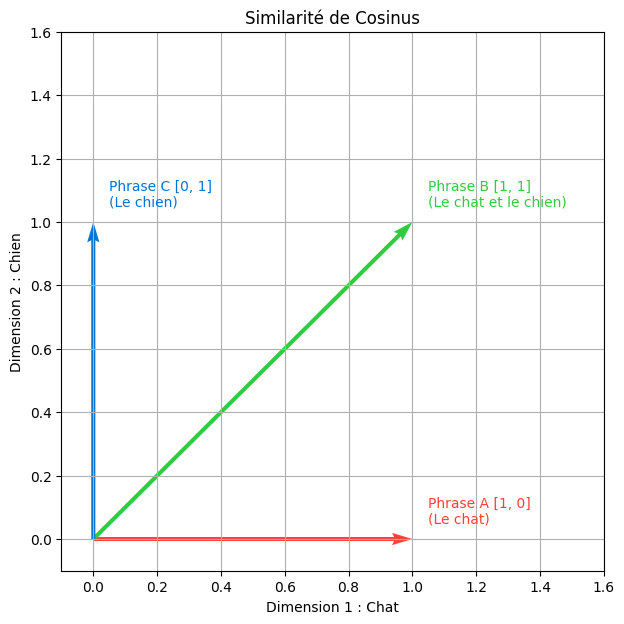

In [48]:
fig, ax = plt.subplots(figsize=(7, 7))

origin = [0, 0, 0], [0, 0, 0]

X = [vect_A[0], vect_B[0], vect_C[0]]
Y = [vect_A[1], vect_B[1], vect_C[1]]

ax.quiver(
    origin[0],
    origin[1],
    X,
    Y,
    color=["#FF4136", "#2ECC40", "#0074D9"],
    angles="xy",
    scale_units="xy",
    scale=1
)

ax.set_xlim(-0.1, 1.6)
ax.set_ylim(-0.1, 1.6)
ax.grid(True)

ax.text(1.05, 0.05, f"Phrase A [1, 0]\n(Le chat)", color="#FF4136")
ax.text(1.05,1.05,f"Phrase B [1, 1]\n(Le chat et le chien)",color="#2ECC40")
ax.text(0.05, 1.05, f"Phrase C [0, 1]\n(Le chien)", color="#0074D9")

ax.set_xlabel("Dimension 1 : Chat" )
ax.set_ylabel("Dimension 2 : Chien")
ax.set_title("Similarité de Cosinus")

plt.show()